In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import sys

In [2]:
# 1. CONFIGURATION AND PARAMETERS

# Using relative paths to ensur reproducibility of research
DATA_DIR = Path("../Data")

# Defining parameters as lists for easy scalability to include additional countries and variables
COUNTRIES = ["Belgium", "Spain", "Poland"]
TASKS_NRCA = ["t_4A2a4", "t_4A2b2", "t_4A4a1"]
max_ISCO_categories = 10 

In [4]:
# 2. FUNCTIONS

def load_and_tidy_employment_data(filepath: Path, countries: list) -> pd.DataFrame:
    """
    Loads ISCO sheets and transforms the data into a standardized 'tidy' format.
    This ensures that data for all countries is stored in a single 'Country' column.
    """
    df_list = []
    for i in range(1, max_ISCO_categories): # Looping through ISCO categories to max_ISCO_categories-1
        df = pd.read_excel(filepath, sheet_name=f"ISCO{i}")
        df['ISCO'] = i
        df_list.append(df)
        
    all_data = pd.concat(df_list, ignore_index=True)
    
    # Transform data into a long format
    melted = all_data.melt( 
        id_vars=['TIME', 'ISCO'], 
        value_vars=countries, 
        var_name='Country',
        value_name='Employment'
    )
    
    # Calculate total employment and percentage shares for each period and country
    totals = melted.groupby(['TIME', 'Country'])['Employment'].transform('sum')
    melted['Share'] = melted['Employment'] / totals
    
    return melted

def standardize_weighted(df: pd.DataFrame, columns: list, weight_col: str = 'Share') -> pd.DataFrame:
    """
    Returns an updated DataFrame with standardized values for the selected columns, using the specified weight column.
    """
    for col in columns:
        std_col_name = f"std_{col}"
        
        weighted_mean = np.average(df[col], weights=df[weight_col])
        weighted_var = np.average((df[col] - weighted_mean)**2, weights=df[weight_col])
        weighted_std = np.sqrt(weighted_var)
        
        df[std_col_name] = (df[col] - weighted_mean) / weighted_std
        
    return df

def plot_trends(df: pd.DataFrame, countries: list, metric_col: str = 'NRCA_weighted'):
    """
    Generates time trend plots for the defined list of countries.
    """
    for country in countries:
        country_data = df[df['Country'] == country]
        
        plt.figure(figsize=(10, 6))
        plt.plot(country_data['TIME'], country_data[metric_col], marker='o', linestyle='-')
        plt.title(f"Non-Routine Cognitive Analytical Tasks Intensity - {country}")
        plt.xlabel("Time")
        plt.ylabel("Standardized NRCA")
        
        # X-axis formatting (display every 2nd label)
        x_ticks = country_data['TIME'].iloc[::2]
        plt.xticks(x_ticks, rotation=45)
        
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

In [5]:
# 3. DATA PROCESSING

# Load and tidy Eurostat employment statistical data
subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

employment_df = load_and_tidy_employment_data(DATA_DIR / "Eurostat_employment_isco.xlsx", COUNTRIES)

# Load the O*NET database and extract the first digit of the ISCO code
task_data = pd.read_csv(DATA_DIR / "onet_tasks.csv")
task_data['ISCO'] = task_data['isco08'].astype(str).str[:1].astype(int)

# Aggregate variables from the task database
agg_tasks = task_data.groupby('ISCO')[TASKS_NRCA].mean().reset_index()

# Merge both datasets using the 'ISCO' identifier
combined = pd.merge(employment_df, agg_tasks, on='ISCO', how='left')

In [6]:
# 4. STANDARDIZATION AND INDICATOR CALCULATION

# Apply standardization independently for each country
combined = combined.groupby('Country', group_keys=False).apply(
    standardize_weighted, columns=TASKS_NRCA
)

# Calculate the base NRCA composite indicator
std_task_cols = [f"std_{task}" for task in TASKS_NRCA]
combined['NRCA'] = combined[std_task_cols].sum(axis=1)

# Re-standardize the obtained NRCA indicator (following the Autor/Acemoglu methodology)
combined = combined.groupby('Country', group_keys=False).apply(
    standardize_weighted, columns=['NRCA']
)

# Calculate values conditioned by employment size and aggregate them over time
combined['NRCA_weighted'] = combined['std_NRCA'] * combined['Share']
trends_df = combined.groupby(['Country', 'TIME'])['NRCA_weighted'].sum().reset_index()

/var/folders/vp/v39f_l8s3n32dzf55_08j3dc0000gn/T/ipykernel_23542/1760090184.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined = combined.groupby('Country', group_keys=False).apply(
/var/folders/vp/v39f_l8s3n32dzf55_08j3dc0000gn/T/ipykernel_23542/1760090184.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined = combined.groupby('Country', group_keys=False).apply(


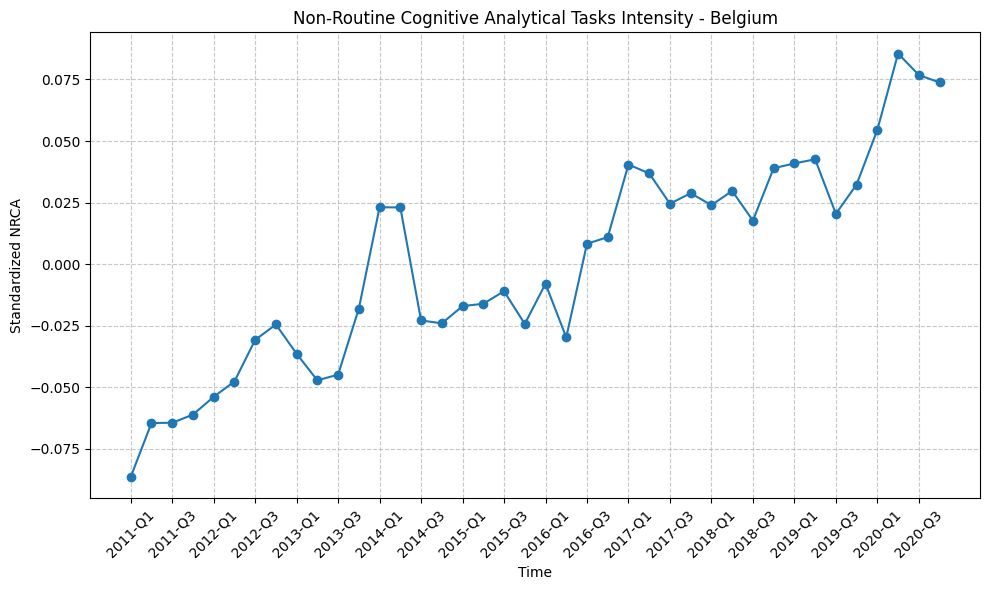

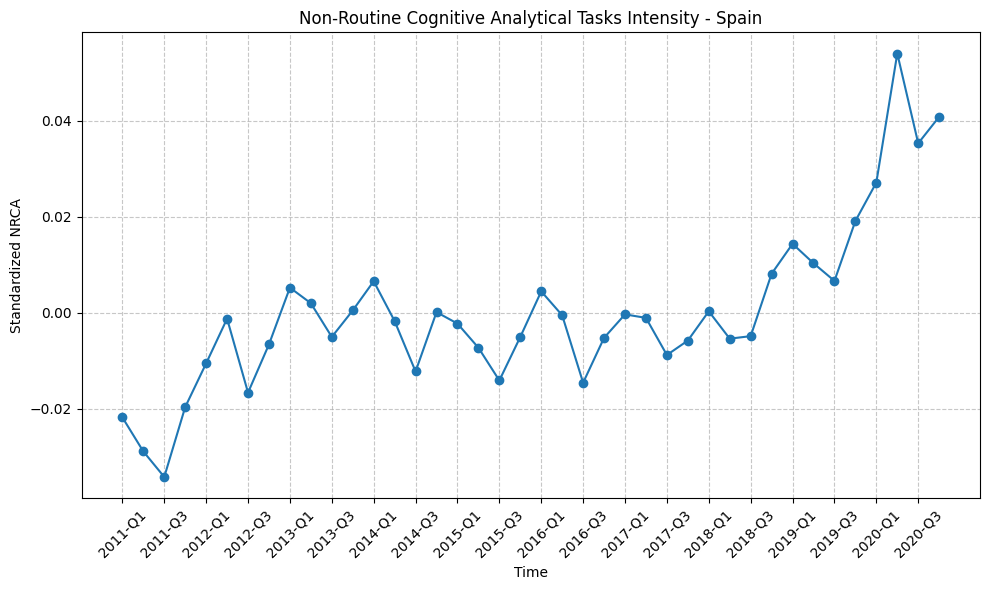

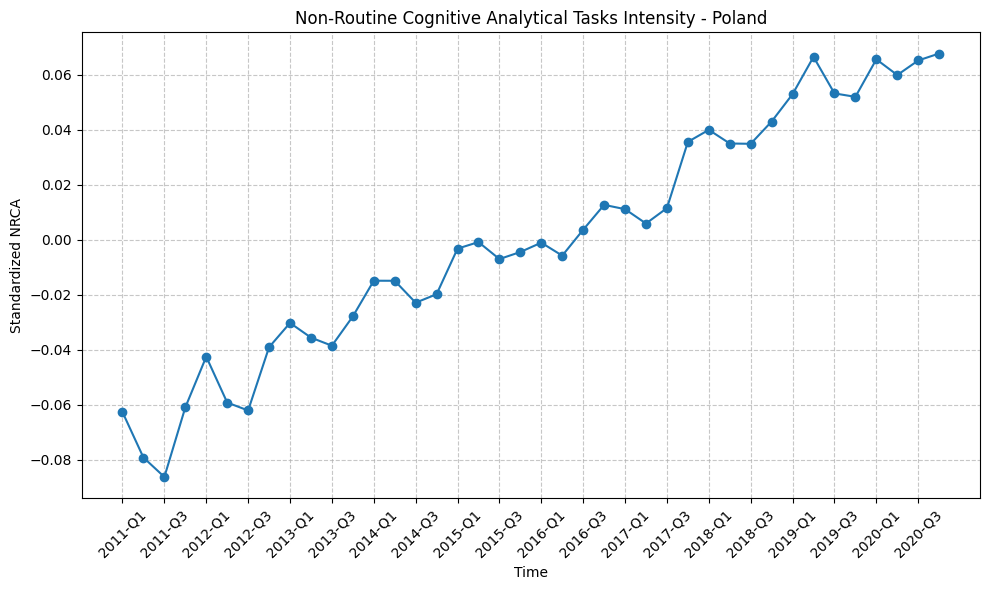

In [7]:
# 5. VISUALIZATION
plot_trends(trends_df, COUNTRIES)